# Plantilla de comparación de algoritmos — Análisis de complejidad práctica

Esta notebook mide empíricamente la complejidad de **dos algoritmos** sobre el mismo problema:
- Repite medidas en ≥8 tamaños y ≥5 repeticiones por tamaño.
- Grafica T(n) vs n y log–log.
- Ajusta modelos asintóticos: `n^k`, `n^k (log n)^b` y `c^n`.
- Genera una conclusión: Θ(·) con parámetros estimados y R².

> Sugerencia: fija los tamaños `NS` y las repeticiones `REPS` de modo que el total quede < 1 min si tu categoría lo exige.

## 🔧 Importaciones y configuración

In [61]:
import time, math, statistics, gc, sys, platform, hashlib, copy, warnings, os, random
from dataclasses import dataclass
from typing import Callable, Any, Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(suppress=True)
SEED_BASE = 123456789
rng_global = np.random.default_rng(SEED_BASE)

print("Python:", sys.version)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("Plataforma:", platform.platform())

@dataclass
class ExperimentConfig:
    ns: List[int]
    reps: int = 7
    warmup: int = 1
    medir_memoria: bool = False
    limite_segundos_por_llamada: float = 2.0
    target_min_wall_ms: float = 60.0   # cada medición durará al menos esto (via loops)
    trim_frac: float = 0.15            # para trimmed mean por (alg,n)
    usar_mad_outliers: bool = True     # filtra repeticiones aberrantes por MAD

@dataclass
class Problem:
    make_input: Callable[[int, int], Any]
    # oráculo de correctitud: si es None, se compara A vs B; si no, se compara con oráculo
    oracle: Optional[Callable[[Any], Any]] = None
    # comparador de salidas: por defecto igualdad exacta
    eq: Callable[[Any, Any], bool] = lambda a, b: a == b


Python: 3.11.9 (v3.11.9:de54cf5be3, Apr  2 2024, 07:12:50) [Clang 13.0.0 (clang-1300.0.29.30)]
Numpy: 2.3.3
Pandas: 2.3.2
Plataforma: macOS-15.6.1-arm64-arm-64bit


## ✍️ Define tus algoritmos A y B (REEMPLAZA)

In [62]:
# Algoritmo A: Bubble Sort (O(n^2))
def bubble_sort(arr):
    a = arr[:]  # copia para no modificar in place
    n = len(a)
    for i in range(n):
        for j in range(0, n-i-1):
            if a[j] > a[j+1]:
                a[j], a[j+1] = a[j+1], a[j]
    return a

# Algoritmo B: Merge Sort (O(n log n))
def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr)//2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return merge(left, right)

def merge(left, right):
    result=[]; i=j=0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i]); i+=1
        else:
            result.append(right[j]); j+=1
    result.extend(left[i:]); result.extend(right[j:])
    return result

# Diccionario para el benchmark
ALGORITMOS = {
    "Burbuja (O(n²))": bubble_sort,
    "MergeSort (O(n log n))": merge_sort,
}
def make_input(n, seed):
    import random
    random.seed(seed)
    return [random.randint(0, 10**6) for _ in range(n)]

# Oráculo: Python sorted()
PROBLEMA = Problem(make_input=make_input, oracle=lambda xs: sorted(xs))


In [63]:
def busqueda_lineal(data):
    lista, objetivo = data
    for idx, n in enumerate(lista):
        if objetivo == n:
            return idx

def busqueda_aleatoria(data):
    lista, objetivo = data
    while True:
        indice_aleatorio = random.randrange(len(lista))
        if lista[indice_aleatorio] == objetivo:
            return indice_aleatorio

ALGORITMOS = {
    "Busqueda lineal": busqueda_lineal,
    "Bogo-search": busqueda_aleatoria,
}

def make_input(n, seed):
    random.seed(seed)
    lista = [random.randint(0, 10**6) for _ in range(n)]
    numero_buscado = random.choice(lista)
    return (lista, numero_buscado)   # empaquetado en tupla

PROBLEMA = Problem(
    make_input=make_input,
    oracle=lambda data: data[0].index(data[1])  # lista.index(objetivo)
)

## ✅ Verificación de correctitud (rápida)

In [64]:
def verifica_correctitud(
    algoritmos: Dict[str, Callable[[Any], Any]],
    problema: Problem,
    ns_prueba: List[int] = [8, 16, 32, 64],
    pruebas_por_n: int = 5
) -> None:
    print("== Verificación de correctitud ==")
    for n in ns_prueba:
        for r in range(pruebas_por_n):
            seed = SEED_BASE + n * 1000 + r
            x = problema.make_input(n, seed)
            if problema.oracle is not None:
                y_ref = problema.oracle(x)
                for nombre, f in algoritmos.items():
                    y = f(copy.deepcopy(x))
                    if not problema.eq(y, y_ref):
                        raise AssertionError(f"Fallo {nombre} n={n} rep={r}")
            else:
                # compara entre algoritmos
                outs = []
                for nombre, f in algoritmos.items():
                    outs.append((nombre, f(copy.deepcopy(x))))
                y0 = outs[0][1]
                for nombre, y in outs[1:]:
                    if not problema.eq(y, y0):
                        raise AssertionError(f"Fallo {outs[0][0]} vs {nombre} n={n} rep={r}")
    print("✔ Correctitud verificada en pruebas pequeñas.")

verifica_correctitud(ALGORITMOS, PROBLEMA)

== Verificación de correctitud ==
✔ Correctitud verificada en pruebas pequeñas.


## ⏱️ Medición robusta (tiempo y memoria opcional)

In [65]:
from contextlib import contextmanager
import tracemalloc

@contextmanager
def maybe_tracemalloc(enabled: bool):
    if enabled:
        tracemalloc.start()
        try: yield
        finally: tracemalloc.stop()
    else:
        yield

def _baseline_touch(x):
    # Toca levemente la entrada para aproximar overhead de llamada/loop
    # sin modificarla (para listas crea una lectura sumaria)
    if isinstance(x, list):
        _ = 0
        for i in range(0, len(x), max(1, len(x)//7)): _ ^= x[i]
        return _
    return 0

def _time_loops(func, x, loops: int) -> float:
    t0 = time.perf_counter_ns()
    for _ in range(loops):
        func(x)
    t1 = time.perf_counter_ns()
    return (t1 - t0) * 1e-9

def _autotune_loops(func, x, target_min_wall_ms: float, max_loops: int = 10_000) -> int:
    # escalado geométrico hasta que supere el umbral o llegue al máximo
    loops = 1
    target = target_min_wall_ms / 1000.0
    while loops <= max_loops:
        dt = _time_loops(func, x, loops)
        if dt >= target: return loops
        loops *= 2
    return max_loops

def medir_una_muestra(func: Callable[[Any], Any], x: Any,
                      warmup: int, medir_memoria: bool,
                      target_min_wall_ms: float) -> Tuple[float, float, int]:
    # Warm-up
    for _ in range(max(0, warmup)): func(x)
    gc.collect()

    # loops adaptativos
    loops = _autotune_loops(func, x, target_min_wall_ms)
    # Overhead baseline
    base_loops = loops
    t_over = _time_loops(lambda z: _baseline_touch(z), x, base_loops)

    pico_kib = float("nan")
    with maybe_tracemalloc(medir_memoria):
        if medir_memoria: tracemalloc.clear_traces()
        t = _time_loops(func, x, loops)
        if medir_memoria:
            current, peak = tracemalloc.get_traced_memory()
            pico_kib = peak / 1024.0
    t_por_llamada = max((t - t_over) / max(1, loops), 0.0)
    return t_por_llamada, pico_kib, loops

def _mad_filter(vals: np.ndarray, c: float = 3.5) -> np.ndarray:
    # True = mantener
    if len(vals) < 5: return np.ones_like(vals, dtype=bool)
    med = np.median(vals)
    mad = np.median(np.abs(vals - med)) + 1e-16
    z = 0.6745 * (vals - med) / mad
    return np.abs(z) <= c

def benchmark(
    algoritmos: Dict[str, Callable[[Any], Any]],
    problema: Problem,
    cfg: ExperimentConfig
) -> pd.DataFrame:
    registros = []
    for n in cfg.ns:
        print(f"n={n} ...", end=" ")
        for rep in range(cfg.reps):
            seed = SEED_BASE + n * 10_000 + rep
            x = problema.make_input(n, seed)
            for nombre, f in algoritmos.items():
                try:
                    t, mem_kib, loops = medir_una_muestra(
                        f, copy.deepcopy(x),
                        warmup=cfg.warmup,
                        medir_memoria=cfg.medir_memoria,
                        target_min_wall_ms=cfg.target_min_wall_ms
                    )
                except Exception as e:
                    t, mem_kib, loops = float("nan"), float("nan"), 1
                    print(f"\nError en {nombre} n={n} rep={rep}: {e}")
                registros.append({
                    "algoritmo": nombre, "n": n, "rep": rep,
                    "tiempo_s": t, "mem_peak_kib": mem_kib, "loops": loops
                })
            # corte preventivo por tiempo (si alguna tardó demasiado)
            if any(r["tiempo_s"] >= cfg.limite_segundos_por_llamada for r in registros[-len(algoritmos):]):
                print("| corte por tiempo", end=" ")
                break
        print("✓")
    df = pd.DataFrame(registros)

    # Agregado robusto
    rows = []
    for (alg, n), sub in df.groupby(["algoritmo", "n"], as_index=False):
        tvals = sub["tiempo_s"].dropna().values
        if cfg.usar_mad_outliers:
            mask = _mad_filter(tvals)
            tvals = tvals[mask]
        tvals.sort()
        k = len(tvals)
        if k == 0:
            rows.append({"algoritmo":alg,"n":n,"tiempo_promedio_s":np.nan,"desv_std_s":np.nan,
                         "repeticiones":0,"ci95_s":np.nan,"min_s":np.nan,"max_s":np.nan,
                         "mem_peak_kib_mean":np.nan})
            continue
        # trimmed mean
        g = int(math.floor(cfg.trim_frac * k))
        t_trim = tvals[g: k - g] if k - 2*g >= 1 else tvals
        mean = float(np.mean(t_trim))
        std = float(np.std(t_trim, ddof=1)) if len(t_trim) >= 2 else 0.0
        ci95 = 1.96 * std / math.sqrt(max(1, len(t_trim)))
        rows.append({
            "algoritmo": alg, "n": n,
            "tiempo_promedio_s": mean, "desv_std_s": std, "ci95_s": ci95,
            "repeticiones": len(t_trim), "min_s": float(np.min(tvals)),
            "max_s": float(np.max(tvals)),
            "mem_peak_kib_mean": float(np.nanmean(sub["mem_peak_kib"]))
        })
    df_sum = pd.DataFrame(rows)
    return df, df_sum

## 📊 Ejecutar experimento

In [66]:
from contextlib import contextmanager
import tracemalloc

@contextmanager
def maybe_tracemalloc(enabled: bool):
    if enabled:
        tracemalloc.start()
        try: yield
        finally: tracemalloc.stop()
    else:
        yield

def _baseline_touch(x):
    # Toca levemente la entrada para aproximar overhead de llamada/loop
    # sin modificarla (para listas crea una lectura sumaria)
    if isinstance(x, list):
        _ = 0
        for i in range(0, len(x), max(1, len(x)//7)): _ ^= x[i]
        return _
    return 0

def _time_loops(func, x, loops: int) -> float:
    t0 = time.perf_counter_ns()
    for _ in range(loops):
        func(x)
    t1 = time.perf_counter_ns()
    return (t1 - t0) * 1e-9

def _autotune_loops(func, x, target_min_wall_ms: float, max_loops: int = 10_000) -> int:
    # escalado geométrico hasta que supere el umbral o llegue al máximo
    loops = 1
    target = target_min_wall_ms / 1000.0
    while loops <= max_loops:
        dt = _time_loops(func, x, loops)
        if dt >= target: return loops
        loops *= 2
    return max_loops

def medir_una_muestra(func: Callable[[Any], Any], x: Any,
                      warmup: int, medir_memoria: bool,
                      target_min_wall_ms: float) -> Tuple[float, float, int]:
    # Warm-up
    for _ in range(max(0, warmup)): func(x)
    gc.collect()

    # loops adaptativos
    loops = _autotune_loops(func, x, target_min_wall_ms)
    # Overhead baseline
    base_loops = loops
    t_over = _time_loops(lambda z: _baseline_touch(z), x, base_loops)

    pico_kib = float("nan")
    with maybe_tracemalloc(medir_memoria):
        if medir_memoria: tracemalloc.clear_traces()
        t = _time_loops(func, x, loops)
        if medir_memoria:
            current, peak = tracemalloc.get_traced_memory()
            pico_kib = peak / 1024.0
    t_por_llamada = max((t - t_over) / max(1, loops), 0.0)
    return t_por_llamada, pico_kib, loops

def _mad_filter(vals: np.ndarray, c: float = 3.5) -> np.ndarray:
    # True = mantener
    if len(vals) < 5: return np.ones_like(vals, dtype=bool)
    med = np.median(vals)
    mad = np.median(np.abs(vals - med)) + 1e-16
    z = 0.6745 * (vals - med) / mad
    return np.abs(z) <= c

def benchmark(
    algoritmos: Dict[str, Callable[[Any], Any]],
    problema: Problem,
    cfg: ExperimentConfig
) -> pd.DataFrame:
    registros = []
    for n in cfg.ns:
        print(f"n={n} ...", end=" ")
        for rep in range(cfg.reps):
            seed = SEED_BASE + n * 10_000 + rep
            x = problema.make_input(n, seed)
            for nombre, f in algoritmos.items():
                try:
                    t, mem_kib, loops = medir_una_muestra(
                        f, copy.deepcopy(x),
                        warmup=cfg.warmup,
                        medir_memoria=cfg.medir_memoria,
                        target_min_wall_ms=cfg.target_min_wall_ms
                    )
                except Exception as e:
                    t, mem_kib, loops = float("nan"), float("nan"), 1
                    print(f"\nError en {nombre} n={n} rep={rep}: {e}")
                registros.append({
                    "algoritmo": nombre, "n": n, "rep": rep,
                    "tiempo_s": t, "mem_peak_kib": mem_kib, "loops": loops
                })
            # corte preventivo por tiempo (si alguna tardó demasiado)
            if any(r["tiempo_s"] >= cfg.limite_segundos_por_llamada for r in registros[-len(algoritmos):]):
                print("| corte por tiempo", end=" ")
                break
        print("✓")
    df = pd.DataFrame(registros)

    # Agregado robusto
    rows = []
    for (alg, n), sub in df.groupby(["algoritmo", "n"], as_index=False):
        tvals = sub["tiempo_s"].dropna().values
        if cfg.usar_mad_outliers:
            mask = _mad_filter(tvals)
            tvals = tvals[mask]
        tvals.sort()
        k = len(tvals)
        if k == 0:
            rows.append({"algoritmo":alg,"n":n,"tiempo_promedio_s":np.nan,"desv_std_s":np.nan,
                         "repeticiones":0,"ci95_s":np.nan,"min_s":np.nan,"max_s":np.nan,
                         "mem_peak_kib_mean":np.nan})
            continue
        # trimmed mean
        g = int(math.floor(cfg.trim_frac * k))
        t_trim = tvals[g: k - g] if k - 2*g >= 1 else tvals
        mean = float(np.mean(t_trim))
        std = float(np.std(t_trim, ddof=1)) if len(t_trim) >= 2 else 0.0
        ci95 = 1.96 * std / math.sqrt(max(1, len(t_trim)))
        rows.append({
            "algoritmo": alg, "n": n,
            "tiempo_promedio_s": mean, "desv_std_s": std, "ci95_s": ci95,
            "repeticiones": len(t_trim), "min_s": float(np.min(tvals)),
            "max_s": float(np.max(tvals)),
            "mem_peak_kib_mean": float(np.nanmean(sub["mem_peak_kib"]))
        })
    df_sum = pd.DataFrame(rows)
    return df, df_sum

In [67]:
def _linreg(X: np.ndarray, y: np.ndarray, w: Optional[np.ndarray]=None):
    if w is not None:
        W = np.diag(w)
        Xw, yw = W @ X, W @ y
        beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
    else:
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    rss = float(np.sum((y - yhat)**2))
    tss = float(np.sum((y - np.mean(y))**2))
    r2  = 1.0 - (rss / tss if tss > 0 else 0.0)
    return beta, yhat, rss, r2

def _aic_bic(y: np.ndarray, yhat: np.ndarray, p: int):
    n = len(y)
    rss = float(np.sum((y - yhat)**2))
    sigma2 = rss / max(n, 1)
    if sigma2 <= 0: sigma2 = 1e-300
    aic  = n * math.log(sigma2) + 2 * p
    aicc = aic + (2*p*(p+1)) / max(n - p - 1, 1e-9) if n > p + 1 else float("inf")
    bic  = n * math.log(sigma2) + p * math.log(max(n, 2))
    return aic, aicc, bic

def _cv_r2_leave_one_n_out(n: np.ndarray, y: np.ndarray, buildX: Callable[[np.ndarray], np.ndarray]) -> float:
    uniq = np.unique(n)
    if len(uniq) < 4: return float("nan")
    sse = 0.0
    y_mean = float(np.mean(y))
    sst = float(np.sum((y - y_mean)**2))
    for uj in uniq:
        mask_tr = (n != uj)
        mask_te = ~mask_tr
        if mask_tr.sum() < 3: return float("nan")
        Xtr = buildX(n[mask_tr]); ytr = y[mask_tr]
        beta, *_ = np.linalg.lstsq(Xtr, ytr, rcond=None)
        Xte = buildX(n[mask_te])
        yhat = Xte @ beta
        sse += float(np.sum((y[mask_te] - yhat)**2))
    return 1.0 - sse / sst if sst > 0 else float("nan")

def _curvatura_loglog(n: np.ndarray, t: np.ndarray) -> float:
    x = np.log(n.astype(float)); y = np.log(t.astype(float))
    if len(x) < 4: return 0.0
    dx = np.diff(x); dy = np.diff(y)
    slope = dy / dx
    return float(slope[-1] - slope[0])  # incremento de pendiente

def fit_modelos(n: np.ndarray, t: np.ndarray, w: Optional[np.ndarray]=None):
    # prepara
    n = np.asarray(n, float); t = np.asarray(t, float)
    mask = (n > 0) & (t > 0) & np.isfinite(t)
    n = n[mask]; t = t[mask]
    if len(n) < 4: return []

    y = np.log(t)
    modelos = []

    # 1) n^k -> log T = log a + k log n
    def X_poly(nv): return np.column_stack([np.ones_like(nv), np.log(nv)])
    X = X_poly(n)
    beta, yhat, rss, r2 = _linreg(X, y, w)
    a = float(np.exp(beta[0])); k = float(beta[1])
    aic, aicc, bic = _aic_bic(y, yhat, p=2)
    cv_r2 = _cv_r2_leave_one_n_out(n, y, X_poly)
    modelos.append({"modelo":"n^k","a":a,"k":k,"b":0.0,"c":float("nan"),
                    "r2":r2,"aicc":aicc,"bic":bic,"cv_r2":cv_r2})

    # 2) n^k (log n)^b -> log T = log a + k log n + b log log n (n>=3)
    mask_ll = n >= 3
    if mask_ll.sum() >= 4:
        def X_polilog(nv): 
            return np.column_stack([np.ones_like(nv), np.log(nv), np.log(np.log(nv))])
        X = X_polilog(n[mask_ll]); y2 = y[mask_ll]
        beta, yhat, rss, r2 = _linreg(X, y2, w=None)
        a = float(np.exp(beta[0])); k = float(beta[1]); b = float(beta[2])
        aic, aicc, bic = _aic_bic(y2, yhat, p=3)
        cv_r2 = _cv_r2_leave_one_n_out(n[mask_ll], y2, X_polilog)
        modelos.append({"modelo":"n^k (log n)^b","a":a,"k":k,"b":b,"c":float("nan"),
                        "r2":r2,"aicc":aicc,"bic":bic,"cv_r2":cv_r2})

    # 3) c^n -> log T = log a + (log c) * n
    def X_exp(nv): return np.column_stack([np.ones_like(nv), nv])
    X = X_exp(n)
    beta, yhat, rss, r2 = _linreg(X, y, w=None)
    a = float(np.exp(beta[0])); c = float(np.exp(beta[1]))
    aic, aicc, bic = _aic_bic(y, yhat, p=2)
    cv_r2 = _cv_r2_leave_one_n_out(n, y, X_exp)
    modelos.append({"modelo":"c^n","a":a,"k":float("nan"),"b":float("nan"),"c":c,
                    "r2":r2,"aicc":aicc,"bic":bic,"cv_r2":cv_r2})

    # Orden preliminar: AICc ↑ calidad ↓ (menor mejor); desempate con CV-R²
    modelos.sort(key=lambda m: (m["aicc"], - (m["cv_r2"] if np.isfinite(m["cv_r2"]) else -1e9)))
    return modelos

def _near_int(x, tol=0.15):
    xi = round(x)
    return xi if abs(x - xi) <= tol else x

def _theta_de_modelo(m: Dict[str,float]) -> str:
    if m["modelo"] == "c^n": return f"Θ({m['c']:.2f}^n)"
    k = m.get("k", 0.0); b = m.get("b", 0.0)
    kd = _near_int(k); bd = _near_int(b)
    if abs(bd) < 1e-9 or bd == 0:
        return f"Θ(n^{kd})"
    else:
        return f"Θ(n^{kd} (log n)^{bd})"

def _consenso_clase(n: np.ndarray, t: np.ndarray, candidatos: List[Dict[str,float]]) -> Tuple[Dict[str,float], Dict[str,Any]]:
    """
    Reglas de consenso para evitar falsos 'c^n':
    - Si 'c^n' NO gana con margen claro en AICc/BIC y la curvatura log-log es baja, descártalo.
    - Usa CV-R² para desempatar.
    - Usa razón de duplicación y pendiente local para clasificar polinomiales.
    """
    n = np.asarray(n, float); t = np.asarray(t, float)
    curv = _curvatura_loglog(n, t)
    # top por AICc
    top = candidatos[0] if candidatos else {}
    # Si top es exponencial pero curvatura < umbral y su ventaja en AICc es pequeña -> prefiero polinomial
    if top and top["modelo"] == "c^n":
        if curv < 0.6:
            if len(candidatos) >= 2:
                delta = candidatos[1]["aicc"] - top["aicc"]
                if delta < 6.0:  # regla AICc: <6 no es evidencia fuerte
                    top = candidatos[1]
    # Métrica de duplicación
    ord_idx = np.argsort(n); nn = n[ord_idx]; tt = t[ord_idx]
    ratios_n = nn[1:] / nn[:-1]
    ratios_t = tt[1:] / tt[:-1]
    # pendiente local en log-log
    k_local = np.diff(np.log(tt)) / np.diff(np.log(nn))
    k_local_mediana = float(np.median(k_local)) if len(k_local)>=1 else float("nan")
    diag = {
        "curv_loglog": curv,
        "k_local_mediana": k_local_mediana,
        "duplicaciones": pd.DataFrame({"n2/n1":ratios_n, "T2/T1":ratios_t})
    }
    return top, diag

In [68]:
def plot_t_vs_n(df_sum: pd.DataFrame):
    plt.figure(figsize=(7,5))
    for alg, sub in df_sum.groupby("algoritmo"):
        sub = sub.sort_values("n")
        plt.errorbar(sub["n"], sub["tiempo_promedio_s"], yerr=sub["ci95_s"],
                     marker="o", linestyle="-", label=alg, capsize=3)
    plt.xlabel("n"); plt.ylabel("Tiempo promedio (s)")
    plt.title("T(n) vs n")
    plt.grid(True, which="both", linestyle="--", alpha=0.3)
    plt.legend(); plt.show()

def _pred_t(ajuste: Dict[str, float], n_vals: np.ndarray) -> np.ndarray:
    if not ajuste: return np.full_like(n_vals, np.nan, dtype=float)
    if ajuste["modelo"] == "c^n": return ajuste["a"] * (ajuste["c"] ** n_vals)
    if ajuste["modelo"].startswith("n^k"):
        k = ajuste.get("k", 0.0); b = ajuste.get("b", 0.0)
        logs = np.log(np.maximum(n_vals, 3))
        return ajuste["a"] * (n_vals ** k) * (logs ** b)
    return np.full_like(n_vals, np.nan, dtype=float)

def plot_loglog_con_ajuste(df_sum: pd.DataFrame, ajustes: Dict[str, Dict[str,float]]):
    plt.figure(figsize=(7,5))
    n_min = df_sum["n"].min(); n_max = df_sum["n"].max()
    n_dense = np.unique(np.geomspace(max(3, n_min), n_max, num=200).astype(int))
    for alg, sub in df_sum.groupby("algoritmo"):
        sub = sub.sort_values("n")
        plt.plot(sub["n"], sub["tiempo_promedio_s"], marker="o", linestyle="", label=f"{alg} (medido)")
        yhat = _pred_t(ajustes.get(alg, {}), n_dense)
        plt.plot(n_dense, yhat, linestyle="-", label=f"{alg} (ajuste)")
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("n (log)"); plt.ylabel("T(n) (s) (log)")
    plt.title("Log–Log: medidas y curvas ajustadas")
    plt.grid(True, which="both", linestyle="--", alpha=0.3)
    plt.legend(); plt.show()

def plot_residuos(n: np.ndarray, t: np.ndarray, ajuste: Dict[str,float], titulo: str):
    if not ajuste: return
    n = np.asarray(n, int); t = np.asarray(t, float)
    y = np.log(t + 1e-300)
    Xn = np.log(n)
    yhat = np.log(_pred_t(ajuste, n) + 1e-300)
    res = y - yhat
    plt.figure(figsize=(7,4))
    plt.plot(n, res, marker="o", linestyle="")
    plt.xscale("log")
    plt.axhline(0, linestyle="--")
    plt.xlabel("n (log)"); plt.ylabel("Residual (log T)")
    plt.title(f"Residuos en espacio log — {titulo}")
    plt.grid(True, which="both", linestyle="--", alpha=0.3)
    plt.show()

def plot_duplicacion(n: np.ndarray, t: np.ndarray, titulo: str):
    ord_idx = np.argsort(n); n = np.asarray(n)[ord_idx]; t = np.asarray(t)[ord_idx]
    if len(n) < 2: return
    r_n = n[1:] / n[:-1]; r_t = t[1:] / t[:-1]
    plt.figure(figsize=(7,4))
    plt.plot(r_n, r_t, marker="o", linestyle="-")
    plt.xlabel("n2 / n1"); plt.ylabel("T(n2) / T(n1)")
    plt.title(f"Razón de duplicación — {titulo}")
    plt.grid(True, which="both", linestyle="--", alpha=0.3)
    plt.show()

def plot_pendiente_local(n: np.ndarray, t: np.ndarray, titulo: str):
    ord_idx = np.argsort(n); n = np.asarray(n)[ord_idx]; t = np.asarray(t)[ord_idx]
    if len(n) < 3: return
    k_local = np.diff(np.log(t)) / np.diff(np.log(n))
    x = (n[1:] + n[:-1]) / 2
    plt.figure(figsize=(7,4))
    plt.plot(x, k_local, marker="o", linestyle="-")
    plt.xscale("log")
    plt.xlabel("n (log)"); plt.ylabel("Pendiente local d log T / d log n")
    plt.title(f"Pendiente local — {titulo}")
    plt.grid(True, which="both", linestyle="--", alpha=0.3)
    plt.show()

## 📊 Ejecutar experimento y análisis

n=500000 ... ✓
n=660000 ... ✓
n=860000 ... ✓
n=1100000 ... ✓
n=1380000 ... ✓
n=1700000 ... ✓
n=2060000 ... ✓


,algoritmo,n,tiempo_promedio_s,desv_std_s,ci95_s,repeticiones,min_s,max_s,mem_peak_kib_mean
0,Bogo-search,500000,0.058895,0.021267,0.018641,5,0.009052,0.103693,NaN
1,Bogo-search,660000,0.050830,0.037758,0.033097,5,0.007476,0.111175,NaN
2,Bogo-search,860000,0.097671,0.065124,0.057084,5,0.014561,0.198054,NaN
3,Bogo-search,1100000,0.090677,0.075398,0.066089,5,0.010615,0.230170,NaN
4,Bogo-search,1380000,0.100193,0.029609,0.025954,5,0.045523,0.226799,NaN
5,Bogo-search,1700000,0.244471,0.143998,0.126220,5,0.063584,0.486596,NaN
6,Bogo-search,2060000,0.042926,0.023705,0.020779,5,0.017876,0.069328,NaN
7,Busqueda lineal,500000,0.003522,0.000853,0.000748,5,0.001378,0.005118,NaN
8,Busqueda lineal,660000,0.002720,0.002594,0.002075,6,0.000750,0.007466,NaN
9,Busqueda lineal,860000,0.002665,0.002988,0.002391,6,0.000078,0.006891,NaN



== Bogo-search ==
n^k: AICc=-2.45 | CV-R²=-1.1671 | R²=0.1061 | k=0.371, b=0.000, a≈4.874e-04
c^n: AICc=-2.04 | CV-R²=-1.9091 | R²=0.0514 | c=1.0000, a≈6.331e-02
n^k (log n)^b: AICc=3.20 | CV-R²=-2.9452 | R²=0.2623 | k=-30.162, b=422.117, a≈4.221e-302
→ Elegido: n^k  ⇒ Θ(n^0.3705683764061718)
   Curvatura log–log: -8.526 | k_local_mediana: 0.069

== Busqueda lineal ==
c^n: AICc=0.56 | CV-R²=-0.1234 | R²=0.3585 | c=1.0000, a≈1.183e-03
n^k: AICc=1.92 | CV-R²=-0.4894 | R²=0.2207 | k=0.782, b=0.000, a≈6.617e-08
n^k (log n)^b: AICc=2.14 | CV-R²=0.0763 | R²=0.7044 | k=79.444, b=-1087.493, a≈inf
→ Elegido: c^n  ⇒ Θ(1.00^n)
   Curvatura log–log: 1.772 | k_local_mediana: 0.382


,algoritmo,modelo_elegido,Theta,k,b,c,a,R2,CV_R2,AICc,BIC
0,Bogo-search,n^k,Θ(n^0.3705683764061718),0.371,0.000,nan,4.874e-04,0.1061,-1.1671,-2.45,-5.56
1,Busqueda lineal,c^n,Θ(1.00^n),nan,nan,1.000,1.183e-03,0.3585,-0.1234,0.56,-2.55


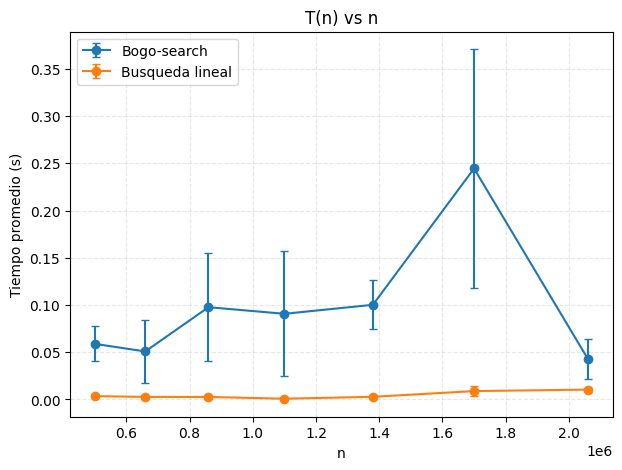

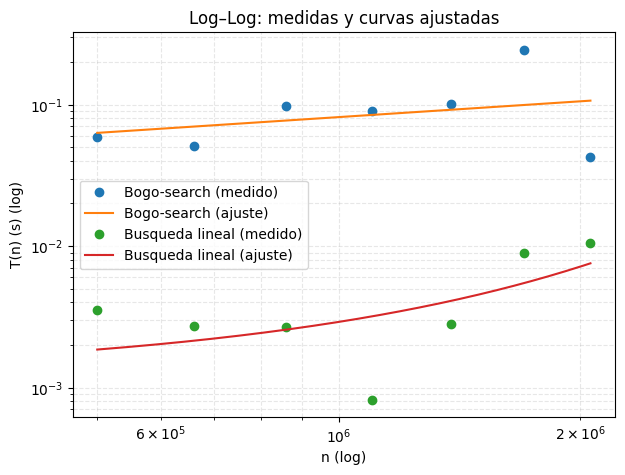

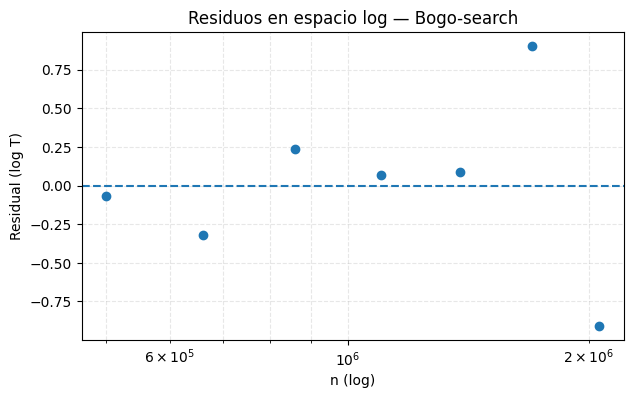

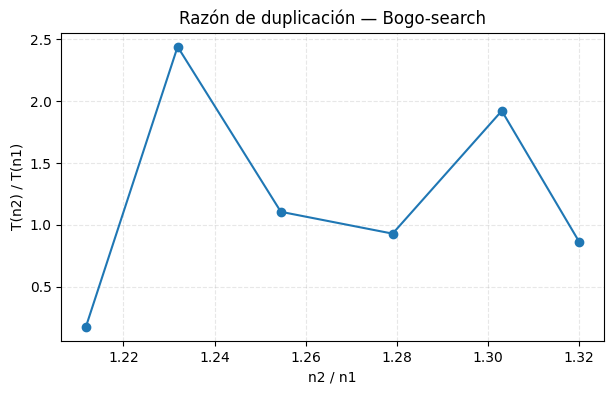

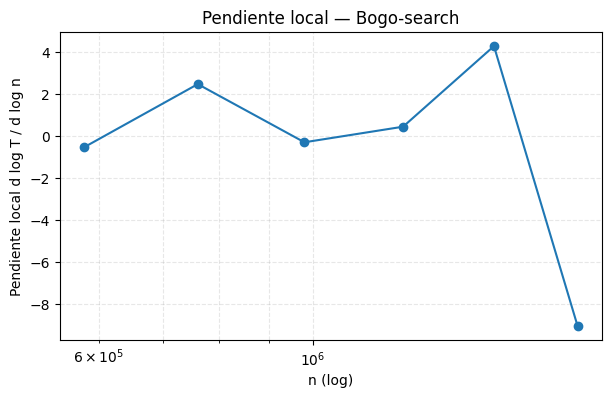

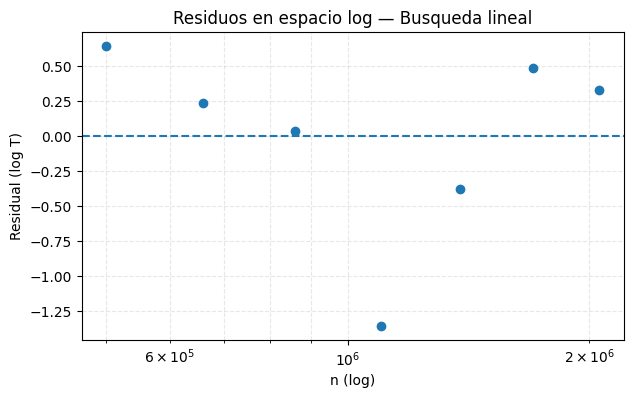

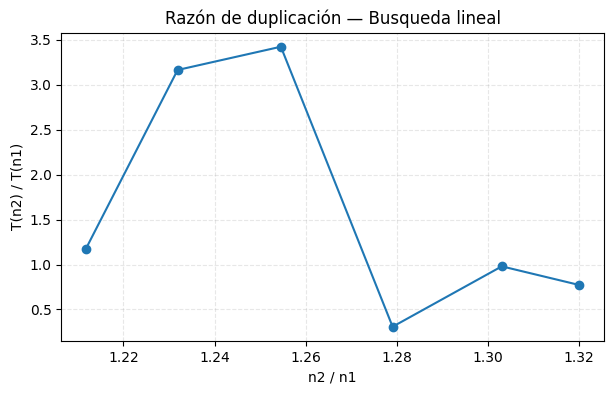

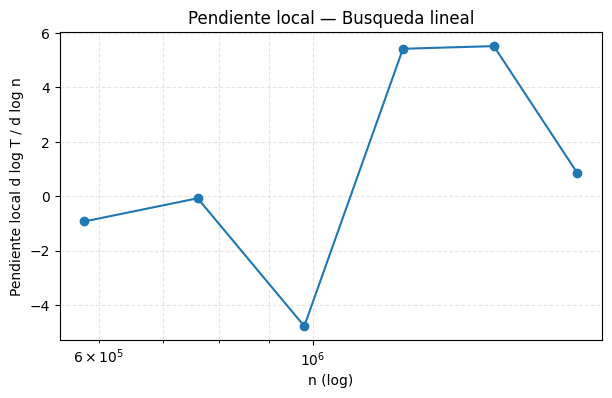

In [71]:
# Elige tamaños que cubran ~8–12 puntos y que, con el límite por llamada, quepan en <1 min
NS   = [
    500_000,
    660_000,
    860_000,
    1_100_000,
    1_380_000,
    1_700_000,
    2_060_000
]
CFG  = ExperimentConfig(ns=NS, reps=7, warmup=1, medir_memoria=False,
                        limite_segundos_por_llamada=20.0, target_min_wall_ms=60.0,
                        trim_frac=0.15, usar_mad_outliers=True)

df_raw, df_sum = benchmark(ALGORITMOS, PROBLEMA, CFG)
display(df_sum)

# Ajuste y selección
ajustes: Dict[str, Dict[str, float]] = {}
diagnosticos: Dict[str, Dict[str, Any]] = {}

for alg, sub in df_sum.groupby("algoritmo"):
    modelos = fit_modelos(sub["n"].values, sub["tiempo_promedio_s"].values)
    if not modelos:
        ajustes[alg] = {}
        continue
    elegido, diag = _consenso_clase(sub["n"].values, sub["tiempo_promedio_s"].values, modelos)
    ajustes[alg] = elegido
    diagnosticos[alg] = diag
    print(f"\n== {alg} ==")
    for m in modelos:
        if m["modelo"].startswith("n^k"):
            print(f"{m['modelo']}: AICc={m['aicc']:.2f} | CV-R²={m['cv_r2']:.4f} | R²={m['r2']:.4f} | k={m['k']:.3f}, b={m['b']:.3f}, a≈{m['a']:.3e}")
        else:
            print(f"{m['modelo']}: AICc={m['aicc']:.2f} | CV-R²={m['cv_r2']:.4f} | R²={m['r2']:.4f} | c={m['c']:.4f}, a≈{m['a']:.3e}")
    print(f"→ Elegido: {elegido['modelo']}  ⇒ { _theta_de_modelo(elegido) }")
    print(f"   Curvatura log–log: {diag['curv_loglog']:.3f} | k_local_mediana: {diag['k_local_mediana']:.3f}")

# Tabla resumen Θ
filas = []
for alg, m in ajustes.items():
    if not m: continue
    filas.append({
        "algoritmo": alg,
        "modelo_elegido": m["modelo"],
        "Theta": _theta_de_modelo(m),
        "k": m.get("k", float("nan")),
        "b": m.get("b", float("nan")),
        "c": m.get("c", float("nan")),
        "a": m.get("a", float("nan")),
        "R2": m.get("r2", float("nan")),
        "CV_R2": m.get("cv_r2", float("nan")),
        "AICc": m.get("aicc", float("nan")),
        "BIC": m.get("bic", float("nan"))
    })
df_modelos = pd.DataFrame(filas)
display(df_modelos.style.format({"k":"{:.3f}","b":"{:.3f}","c":"{:.3f}","a":"{:.3e}","R2":"{:.4f}","CV_R2":"{:.4f}","AICc":"{:.2f}","BIC":"{:.2f}"}))

# Gráficas
plot_t_vs_n(df_sum)
plot_loglog_con_ajuste(df_sum, ajustes)

# Plots de diagnóstico por algoritmo
for alg, sub in df_sum.groupby("algoritmo"):
    n = sub["n"].values; t = sub["tiempo_promedio_s"].values
    plot_residuos(n, t, ajustes[alg], alg)
    plot_duplicacion(n, t, alg)
    plot_pendiente_local(n, t, alg)
